# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

Answer: Adding a penalty to the mean squared error helps control how large the model parameters can get. Squaring keeps all the features but just makes their weights smaller/have less influence on the model. For absolute values, it essentially removes the weights of some features, keeping only what is more important.

2. How does regularization provide a way of exploring the bias-variance trade-off?

Answer: It allows people to adjust how strong the penalty is on the model. Smaller penalty, the lower the bias and the higher the variance. The larger the penalty, the simpler the model which results in higher bias and lower variance. This allows us to find the right balance between bias-variance.


3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

Answer: The main difference between LASSO and Ridge regression is how they penalize the model parameters. LASSO will make coefficients essentially dissappear from the model while Ridge can make them really small, but keep them in the model. LASSO makes a simpler model with fewer features while Rige has many features but makes them just less influencial.


4. How do we typically scale variables for use in regularized regression? Why?

Answer: We typically scale variables with normalization for numeric variables because we want to make our variables be on a similar scale so that the variables are not weighted unfairly. Standardization can also be used too to center the data and do the same thing but just more resistant to outliers.


5. How is the penalty $\alpha$ typically selected?

Answer: We use cross-validation. We pick $\alpha$ based on a grid of values, train the model on training folds, and evaluate performance on validation folds. We choose the $\alpha$  that gives the lowest cross-validated error, which helps balance model complexity and the bias-variance trade-off.


6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

Answer: When conducting cross-validation, we do not include the penalty term when evaluating the cross-validated MSE. We only measure the prediction error on the validation data. This is because the goal of cross-validation is to see how well the model generalizes to new data, and the penalty term is only used during training to control model complexity, not as part of prediction error.



**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV, lasso_path
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [57]:
# 2.1
df2 = pd.read_csv("/workspace/scratchpad/data/cars_hw.csv", encoding = 'latin-1')
df2.columns

Index(['Unnamed: 0', 'Make', 'Make_Year', 'Color', 'Body_Type', 'Mileage_Run',
       'No_of_Owners', 'Seating_Capacity', 'Fuel_Type', 'Transmission',
       'Transmission_Type', 'Price'],
      dtype='object')

In [71]:
df2["Age"] = 2026 - df2["Make_Year"]

X = df2[["Mileage_Run", "Age"]]

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [72]:
# 2.2
from sklearn.linear_model import LinearRegression

model22 = LinearRegression()
model22.fit(X_scaled, df2['Price'])

feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])
print(f'Model intercept: {model22.intercept_}')

coef_df = pd.DataFrame({
    'variable': feature_names,
    'coefficient': model22.coef_
})

print(coef_df)

# sign is negative for the interaction between Mileage_Run and Age

Model intercept: 741019.4672131148
            variable   coefficient
0        Mileage_Run  9.117748e+05
1                Age -2.481722e+05
2      Mileage_Run^2 -2.072926e+05
3    Mileage_Run Age -1.671212e+06
4              Age^2  3.505507e+05
5      Mileage_Run^3 -6.514490e+04
6  Mileage_Run^2 Age  3.388195e+05
7  Mileage_Run Age^2  7.167816e+05
8              Age^3 -2.100379e+05


In [76]:
# 2.3
alpha_grid = np.logspace(1, 3, num=20)
model22 = LassoCV(cv=20, 
                alphas=alpha_grid,
                random_state=100,
                max_iter=100000)
model22 = model22.fit(X_scaled, df2['Price'])

index_star = np.argmin( np.median(model22.mse_path_,axis=1) )
alpha_star = model22.alphas_[index_star]

In [78]:
from sklearn.linear_model import Lasso

coefs = []
for alpha in alpha_grid:
    model = Lasso(alpha=alpha, max_iter=100000)
    model.fit(X_scaled, y)
    coefs.append(model.coef_)

coefs = np.array(coefs)
coef_df = pd.DataFrame(coefs, columns=feature_names)

Optimal cost hyperparameter: 1000.0


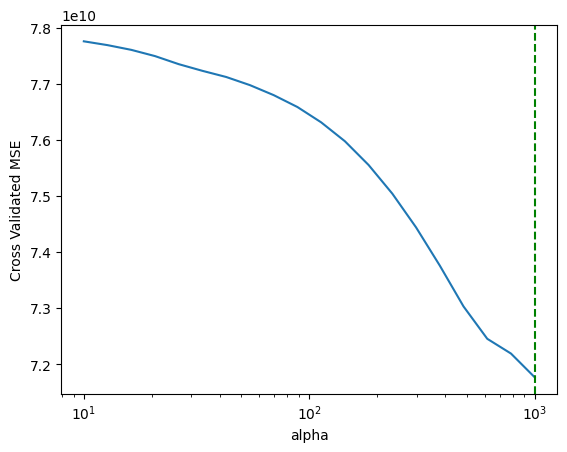

In [79]:
# 2.4
sns.lineplot( x=model22.alphas_, y= np.median(model22.mse_path_,axis=1) )
plt.axvline(x=alpha_star, color='green', linestyle='--', 
            linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star}')


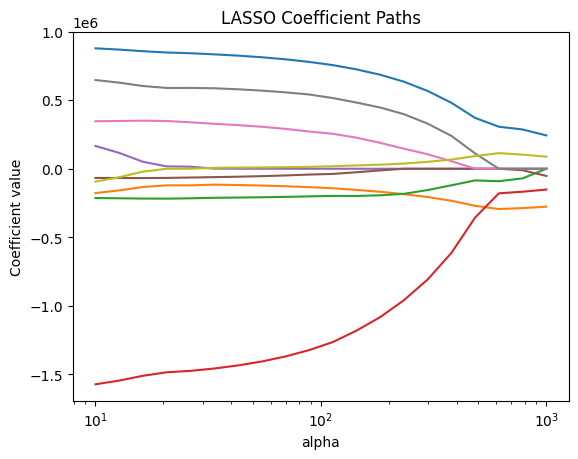

In [80]:
# 2.5
plt.figure()
for i in range(len(feature_names)):
    plt.plot(alpha_grid, coef_df.iloc[:, i], label=feature_names[i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.show()

In [81]:
# 2.6

print(feature_names[model22.coef_ != 0])

# Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3'
# 2/9 are set equal to 0.

['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Mileage_Run^3'
 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']


In [ ]:
# 2.7
comparison = pd.DataFrame({
    "feature": feature_names,
    "linear": model22.coef_,
    "lasso": model22.coef_
})

print(comparison)

# No coefficients increase in magnitude, and none of them change sign.

             feature        linear         lasso
0        Mileage_Run  7.790762e+05  7.790762e+05
1                Age -1.339534e+05 -1.339534e+05
2      Mileage_Run^2 -2.015634e+05 -2.015634e+05
3    Mileage_Run Age -1.322419e+06 -1.322419e+06
4              Age^2  0.000000e+00  0.000000e+00
5      Mileage_Run^3 -4.240952e+04 -4.240952e+04
6  Mileage_Run^2 Age  2.715062e+05  2.715062e+05
7  Mileage_Run Age^2  5.415432e+05  5.415432e+05
8              Age^3  1.374220e+04  1.374220e+04


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [2]:
# 3.1

df3 = pd.read_csv("/workspace/scratchpad/data/heart_failure_clinical_records_dataset.csv", encoding = 'latin-1')

df3.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
X3 = df3[["age", "ejection_fraction", "serum_creatinine"]]
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly3 = poly3.fit_transform(X3)

scaler3 = StandardScaler()
X_poly3_scaled = scaler3.fit_transform(X_poly3)

X31 = df3[["anaemia", "diabetes", "high_blood_pressure", "smoking"]]
poly_cat = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_cat = poly_cat.fit_transform(X31)


Xconcat = np.concatenate((X_poly3_scaled, X_cat), axis=1)

In [4]:
# 3.2

y3 = df3["DEATH_EVENT"]
model32 = LinearRegression()
model32.fit(Xconcat, y3)

# Feature names
poly_names = poly3.get_feature_names_out(['age', 'ejection_fraction', 'serum_creatinine'])
cat_names = poly_cat.get_feature_names_out(['anaemia', 'diabetes', 'high_blood_pressure', 'smoking'])
all_feature_names = np.concatenate([poly_names, cat_names])

# Coefficients table
coef_df3 = pd.DataFrame({
    'variable': all_feature_names,
    'coefficient': model32.coef_
})

print(coef_df3)

                                  variable  coefficient
0                                      age     1.539156
1                        ejection_fraction    -2.192494
2                         serum_creatinine    -0.853588
3                                    age^2    -3.678654
4                    age ejection_fraction    -0.600918
5                     age serum_creatinine     1.841563
6                      ejection_fraction^2     3.430976
7       ejection_fraction serum_creatinine     2.673394
8                       serum_creatinine^2    -2.647041
9                                    age^3     1.993135
10                 age^2 ejection_fraction     0.908026
11                  age^2 serum_creatinine    -0.697522
12                 age ejection_fraction^2    -0.081206
13  age ejection_fraction serum_creatinine    -1.577665
14                  age serum_creatinine^2     1.284099
15                     ejection_fraction^3    -1.250341
16    ejection_fraction^2 serum_creatinine    -1

Counterintuitive? Yes for age considering as you get older you're more likely to die but it's positive in the model for some reason. serum_creatinine also seems to be similar in the sense that it's negative when it should probability have a positive coefficient. The inclusion of higher-order powers of interactions might resolve the apparent contradiction by getting nonlinear relationships that can be combined to still get the real relationship.

In [5]:
# 3.3
alphas = np.logspace(-5, 5, num=30)

model33 = LassoCV(cv=20,
                alphas=alphas,
                random_state=100,
                max_iter=100000)
model33.fit(Xconcat, y3)

index_star33 = np.argmin( np.median(model33.mse_path_,axis=1) )
alpha_star33 = model33.alphas_[index_star33]

Optimal cost hyperparameter: 0.012689610031679234


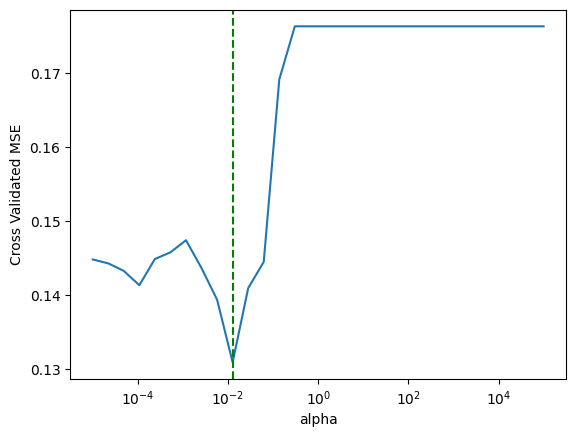

In [6]:
# 3.4
sns.lineplot( x=model33.alphas_, y= np.median(model33.mse_path_,axis=1) )
plt.axvline(x=alpha_star33, color='green', linestyle='--', 
            linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star33}')

In [7]:
# 3.5
from sklearn.linear_model import Lasso

coefs = []
for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=100000)
    model.fit(Xconcat, y3)
    coefs.append(model.coef_)

coefs = np.array(coefs)
coef_df = pd.DataFrame(coefs, columns=all_feature_names)

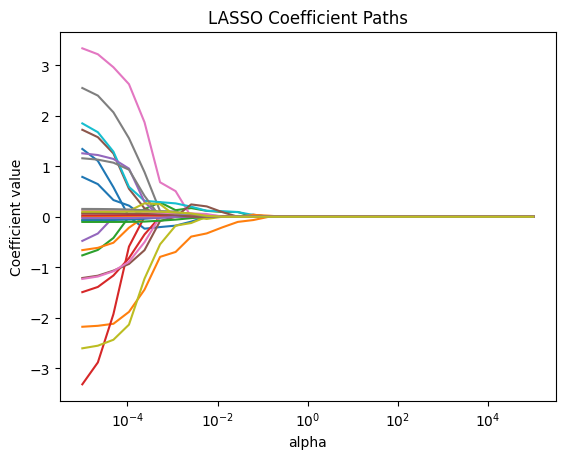

In [8]:
plt.figure()
for i in range(len(all_feature_names)):
    plt.plot(alphas, coef_df.iloc[:, i], label=all_feature_names[i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.show()

In [ ]:
print(all_feature_names[model33.coef_ != 0])

['ejection_fraction' 'serum_creatinine' 'age^3' 'ejection_fraction^3'
 'ejection_fraction^2 serum_creatinine' 'serum_creatinine^3' 'anaemia'
 'diabetes' 'high_blood_pressure' 'diabetes high_blood_pressure'
 'diabetes smoking' 'high_blood_pressure smoking']


In [10]:
np.sum(model33.coef_ != 0)/len(model33.coef_)

np.float64(0.41379310344827586)

In [11]:
lasso_df = pd.DataFrame({
    "feature": all_feature_names,
    "lasso": model33.coef_
})

lasso_df

,feature,lasso
0,age,-0.000000
1,ejection_fraction,-0.329656
2,serum_creatinine,0.116875
3,age^2,0.000000
4,age ejection_fraction,-0.000000
5,age serum_creatinine,0.000000
6,ejection_fraction^2,0.000000
7,ejection_fraction serum_creatinine,0.000000
8,serum_creatinine^2,-0.000000
9,age^3,0.117992


# 3.6

Features selected: ['ejection_fraction' 'serum_creatinine' 'age^3' 'ejection_fraction^3'
 'ejection_fraction^2 serum_creatinine' 'serum_creatinine^3' 'anaemia'
 'diabetes' 'high_blood_pressure' 'diabetes high_blood_pressure'
 'diabetes smoking' 'high_blood_pressure smoking']

Proportion: 0.41379310344827586

Comparison: From what I saw, none of the LASSO coefficients had larger magnitudes compared to the linear regression. They also don't seem to really change signs. The sign patterns seems to make more sense for Lasso. In terms of bias-variance trade-off, this is because the penalty is more punishing for LASSO  because it makes the model less sensitive to noise. Lasso does have some more bias by essentially removing/making smaller values for coefficients, but this reduces variance. Therefore it just makes it more stable compared to the extreme values that linear regression has.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?